# Session 6 — Spark Operations & Architecture

**Modern Data Engineering Course · Week 3 · Session 2 of 2**
*Instructor: Ameer Ul Islam · In partnership with Interactive Cares*

---

## What you'll learn today

In Session 5 you learned **what Spark is** and **how to load data**. Today you'll learn **how Spark actually computes things — and why it's fast.**

By the end of this session you'll be able to:

1. **Distinguish transformations from actions** — and know why your `.filter()` didn't do anything until you called `.show()`
2. **Read a Spark execution plan** with `.explain()` and understand what the optimizer did
3. **Use the core transformation toolbox** — `select`, `filter`, `withColumn`, `groupBy`, `orderBy`, `join`
4. **Query DataFrames with Spark SQL** as an alternative to the DataFrame API
5. **See — with your own timer — why Spark beats Pandas on multi-GB data**

> 💡 **Setup reminder:** this notebook expects two files alongside it:
> - `dhaka_rides.csv` (500 rows, same as Session 5)
> - `nyc_taxi_jan2024.parquet` (~3M NYC taxi rows, ~75 MB)
>
> If you'd rather use the **real** NYC TLC data, download from:
> `https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet`
> (Same schema, ~3M rows.)


## 1. Quick recap & today's setup

From Session 5: a **SparkSession** is your entry point. Spark splits a big DataFrame into **partitions**, and **executors** process each partition in parallel.

Let's spin up a session and load the Dhaka rides — same as last session:


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, DateType
)

spark = (
    SparkSession.builder
        .appName("Session6_Operations")
        .master("local[*]")
        .getOrCreate()
)

# Reduce log noise — comment this out if you want to see Spark internals
spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Default partitions: {spark.sparkContext.defaultParallelism}")


Spark version: 3.5.4
Default partitions: 10


In [3]:
# Load Dhaka rides with explicit schema (the production way, from Session 5)
rides_schema = StructType([
    StructField("ride_id",   StringType(), False),
    StructField("rider",     StringType(), True),
    StructField("pickup",    StringType(), True),
    StructField("dropoff",   StringType(), True),
    StructField("fare_bdt",  DoubleType(), True),
    StructField("status",    StringType(), True),
    StructField("ride_date", DateType(),   True),
])

rides = (
    spark.read
        .option("header", True)
        .schema(rides_schema)
        .csv("dhaka_rides.csv")
)

print(f"Loaded {rides.count()} rides")
rides.show(5)


Loaded 500 rides
+-------+------+---------+---------+--------+---------+----------+
|ride_id| rider|   pickup|  dropoff|fare_bdt|   status| ride_date|
+-------+------+---------+---------+--------+---------+----------+
|  R0001| Rahim| Farmgate|  Gulshan|  650.99|completed|2024-01-29|
|  R0002| Layla|   Banani|  Gulshan|  146.94|completed|2024-01-05|
|  R0003| Tariq|Dhanmondi|   Banani|  259.15|cancelled|2024-01-04|
|  R0004| Layla|Old Dhaka|   Mirpur|  403.03|completed|2024-03-16|
|  R0005|Zainab|   Uttara|Dhanmondi|  617.57|completed|2024-02-05|
+-------+------+---------+---------+--------+---------+----------+
only showing top 5 rows



## 2. The lazy reveal

Here's something strange. Run the cell below and pay attention to **how long it takes**:


In [4]:
import time

# This pipeline does a LOT of work — filter, transform, group, sort
t0 = time.time()

big_pipeline = (
    rides
        .filter(rides.status == "completed")
        .filter(rides.fare_bdt > 200)
        .select("ride_id", "rider", "pickup", "fare_bdt")
)

t1 = time.time()
print(f"Pipeline 'built' in {(t1 - t0) * 1000:.1f} milliseconds")
print(f"Type of result: {type(big_pipeline).__name__}")


Pipeline 'built' in 54.3 milliseconds
Type of result: DataFrame


That ran in about a millisecond — instant. But we just told Spark to filter twice and project four columns. Did Spark do all that work in 1 ms?

**No. It did almost nothing.**

What you got back is not the filtered data. It's a **plan** — a description of what *would* happen if you asked for the result.

Now let's actually ask for the result:


In [5]:
t0 = time.time()
count = big_pipeline.count()
t1 = time.time()

print(f"Count: {count}")
print(f"Took {(t1 - t0) * 1000:.1f} ms — THIS is when the work happened")


Count: 328
Took 179.4 ms — THIS is when the work happened


**Now** Spark went and did the work. Calling `.count()` is what triggered the filtering.

This is **lazy evaluation**, and it's the single most important concept in Spark.

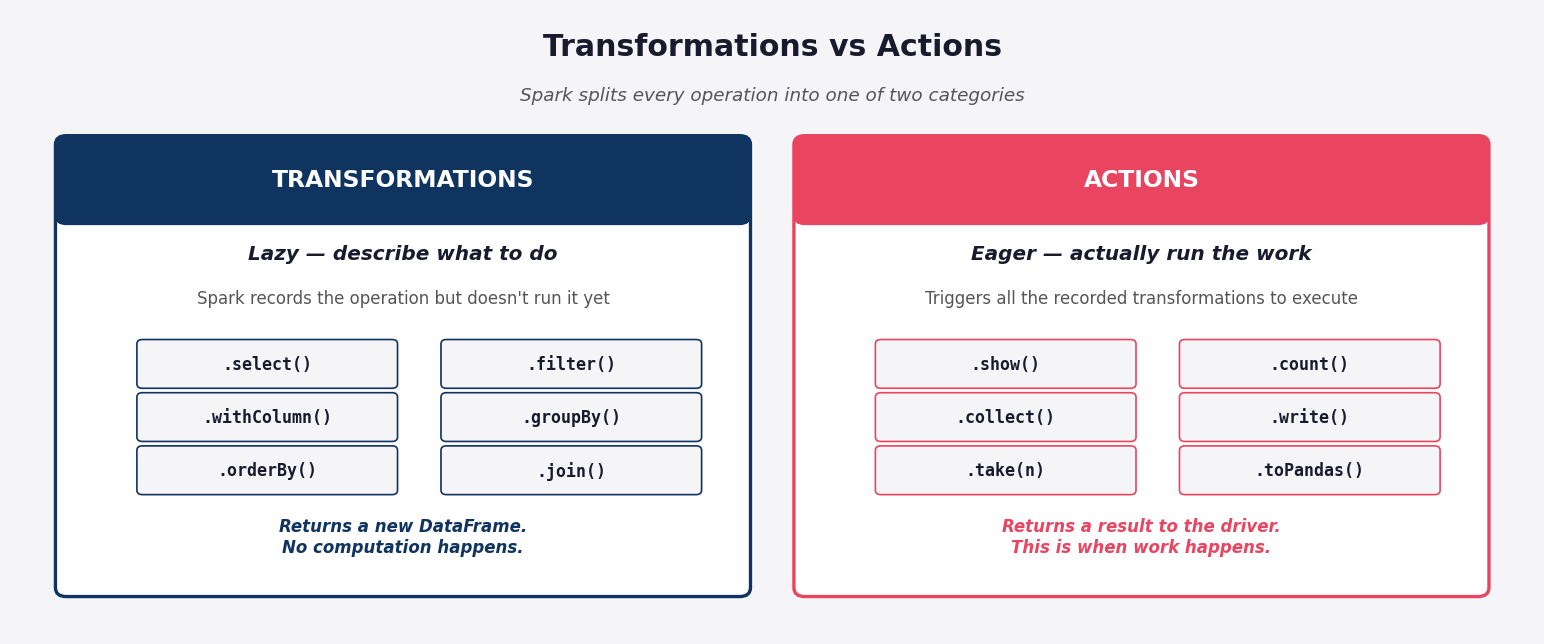

### The rule

| | Transformations | Actions |
|---|---|---|
| When does work happen? | Never — they just describe the plan | Now — they trigger the plan to run |
| What do they return? | A new DataFrame | A real value (number, list, file written) |
| Examples | `.select()`, `.filter()`, `.withColumn()`, `.groupBy()`, `.orderBy()`, `.join()` | `.show()`, `.count()`, `.collect()`, `.write()`, `.take()` |

> 🔑 **The aha moment:** Spark doesn't run code top-to-bottom like Python. It collects all your transformations into a recipe, then waits for an action before cooking. This is why Spark can be smart about *how* it cooks.


## 3. Why lazy is faster — the Catalyst Optimizer

If Spark were eager (like Pandas), it would have to filter immediately, then filter again, then select. Three full passes over the data.

Because Spark is lazy, it can **see your whole pipeline before running anything** — and rearrange it for speed. This is called the **Catalyst Optimizer**.

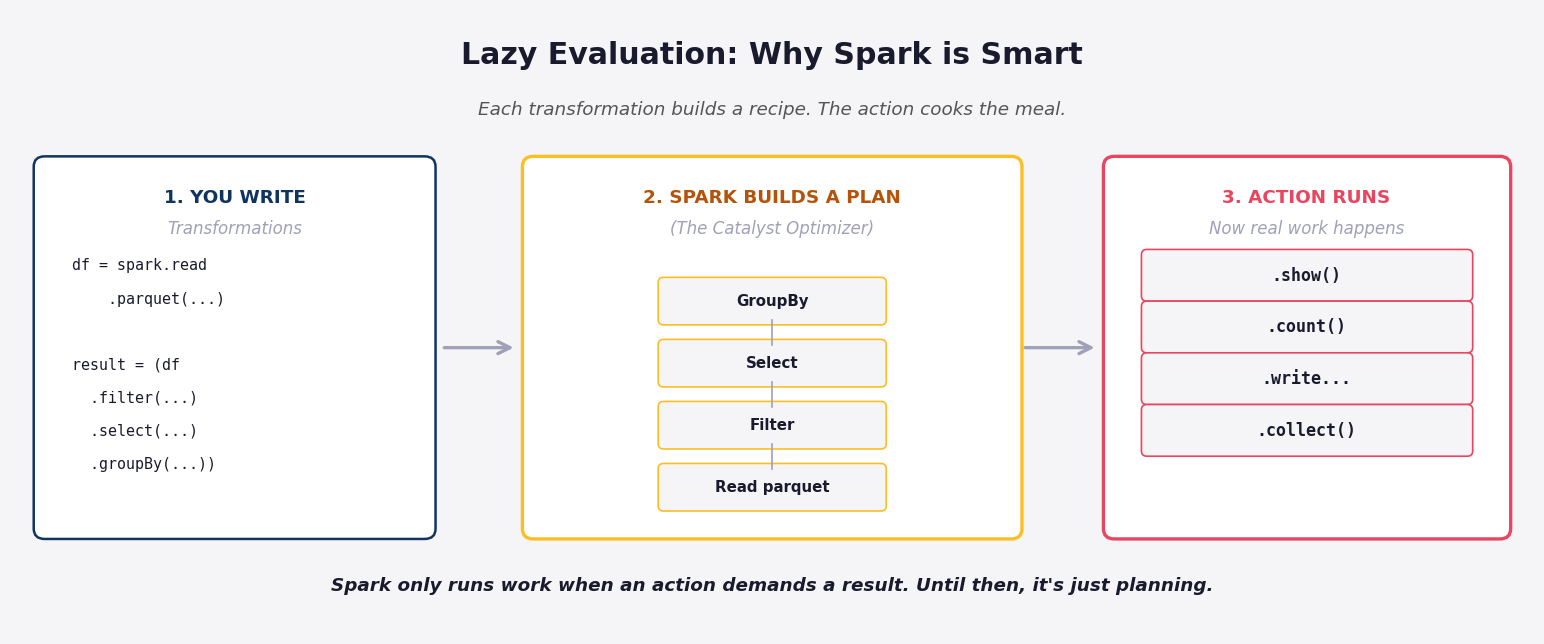

Let's see Catalyst at work using `.explain()`:


In [6]:
# A pipeline that asks "how many completed rides over 200 BDT, by pickup area?"
pipeline = (
    rides
        .filter(rides.status == "completed")
        .filter(rides.fare_bdt > 200)
        .groupBy("pickup")
        .count()
)

# Show what Spark plans to do
pipeline.explain()


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[pickup#2], functions=[count(1)])
   +- Exchange hashpartitioning(pickup#2, 200), ENSURE_REQUIREMENTS, [plan_id=101]
      +- HashAggregate(keys=[pickup#2], functions=[partial_count(1)])
         +- Project [pickup#2]
            +- Filter (((isnotnull(status#5) AND isnotnull(fare_bdt#4)) AND (status#5 = completed)) AND (fare_bdt#4 > 200.0))
               +- FileScan csv [pickup#2,fare_bdt#4,status#5] Batched: false, DataFilters: [isnotnull(status#5), isnotnull(fare_bdt#4), (status#5 = completed), (fare_bdt#4 > 200.0)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/Users/ameerulislam/Documents/interactivecares-data-engineering/L..., PartitionFilters: [], PushedFilters: [IsNotNull(status), IsNotNull(fare_bdt), EqualTo(status,completed), GreaterThan(fare_bdt,200.0)], ReadSchema: struct<pickup:string,fare_bdt:double,status:string>




There are four sections in the output. Read them top-to-bottom:

| Section | What it shows |
|---|---|
| **Parsed Logical Plan** | What you literally wrote, parsed |
| **Analyzed Logical Plan** | Same, but with column types resolved |
| **Optimized Logical Plan** | What Catalyst rewrote it to |
| **Physical Plan** | The actual operations Spark will run |

### What did the optimizer do here?

Look at the **Optimized Logical Plan**. Notice how the two `Filter` operations got combined into one with `AND`:

```
Filter ((status = completed) AND (fare_bdt > 200))
```

That's **one** scan of the data instead of two — for free, because we let Spark see the whole pipeline before running it.

> 💡 **Other optimizations Catalyst does automatically:**
> - **Predicate pushdown** — pushes filters down to the file reader (Parquet only reads matching rows)
> - **Column pruning** — only reads columns you actually use
> - **Constant folding** — evaluates expressions like `1 + 1` once, not per-row
>
> All for free, just because you gave it the whole recipe before saying "go."


### The Pandas trap

The same code in Pandas would run each step immediately, in order:

```python
# Pandas — every line runs immediately, no optimization possible
result = df[df['status'] == 'completed']    # full scan, builds new DataFrame
result = result[result['fare_bdt'] > 200]   # full scan again, builds new DataFrame
result = result.groupby('pickup').size()    # full scan again
```

Three passes over the data. Pandas can't optimize because it doesn't know what's coming next.

This is why Spark scales to data sizes Pandas can't touch — not because Spark's individual operations are faster, but because Spark sees the *whole pipeline* and runs it cleverly.


## 4. The transformation toolbox

Six transformations cover ~90% of the data engineering work you'll do. Let's go through each one with the Dhaka rides.

### 4.1 `.select()` — pick columns

The Spark equivalent of `df[['col1', 'col2']]` in Pandas:


In [7]:
# Three ways to do the same select — pick whichever feels readable

# 1. Plain string column names
rides.select("ride_id", "rider", "fare_bdt").show(3)

# 2. Attribute-style: df.col_name (only works for simple column names)
rides.select(rides.ride_id, rides.rider, rides.fare_bdt).show(3)

# 3. col() function — needed when you want to rename, add expressions, etc.
from pyspark.sql.functions import col
rides.select(col("ride_id"), col("fare_bdt")).show(3)


+-------+-----+--------+
|ride_id|rider|fare_bdt|
+-------+-----+--------+
|  R0001|Rahim|  650.99|
|  R0002|Layla|  146.94|
|  R0003|Tariq|  259.15|
+-------+-----+--------+
only showing top 3 rows

+-------+-----+--------+
|ride_id|rider|fare_bdt|
+-------+-----+--------+
|  R0001|Rahim|  650.99|
|  R0002|Layla|  146.94|
|  R0003|Tariq|  259.15|
+-------+-----+--------+
only showing top 3 rows

+-------+--------+
|ride_id|fare_bdt|
+-------+--------+
|  R0001|  650.99|
|  R0002|  146.94|
|  R0003|  259.15|
+-------+--------+
only showing top 3 rows



### 4.2 `.filter()` — keep rows that match a condition

Two equivalent syntaxes — they produce identical execution plans:


In [8]:
# Pythonic syntax
high_fares = rides.filter(rides.fare_bdt > 500)
high_fares.show(5)

# SQL-string syntax (often cleaner for complex conditions)
rides.filter("fare_bdt > 500 AND status = 'completed'").show(5)


+-------+------+---------+---------+--------+---------+----------+
|ride_id| rider|   pickup|  dropoff|fare_bdt|   status| ride_date|
+-------+------+---------+---------+--------+---------+----------+
|  R0001| Rahim| Farmgate|  Gulshan|  650.99|completed|2024-01-29|
|  R0005|Zainab|   Uttara|Dhanmondi|  617.57|completed|2024-02-05|
|  R0010|Mariam| Farmgate|   Mirpur|  838.62|completed|2024-01-13|
|  R0011|  Omar|Mohakhali|   Uttara|  569.48|completed|2024-01-21|
|  R0012| Tariq|Motijheel|Mohakhali|  596.03|completed|2024-03-18|
+-------+------+---------+---------+--------+---------+----------+
only showing top 5 rows

+-------+------+---------+---------+--------+---------+----------+
|ride_id| rider|   pickup|  dropoff|fare_bdt|   status| ride_date|
+-------+------+---------+---------+--------+---------+----------+
|  R0001| Rahim| Farmgate|  Gulshan|  650.99|completed|2024-01-29|
|  R0005|Zainab|   Uttara|Dhanmondi|  617.57|completed|2024-02-05|
|  R0010|Mariam| Farmgate|   Mirpur| 

### 4.3 `.withColumn()` — add or replace a column

This is your workhorse for derived columns. Like Pandas' `df['new_col'] = ...`:


In [9]:
from pyspark.sql.functions import col, when, round as spark_round

# Add a column that converts BDT to USD (rough rate: 1 USD ≈ 110 BDT)
rides_with_usd = rides.withColumn(
    "fare_usd",
    spark_round(col("fare_bdt") / 110, 2)
)

rides_with_usd.select("ride_id", "fare_bdt", "fare_usd").show(5)


+-------+--------+--------+
|ride_id|fare_bdt|fare_usd|
+-------+--------+--------+
|  R0001|  650.99|    5.92|
|  R0002|  146.94|    1.34|
|  R0003|  259.15|    2.36|
|  R0004|  403.03|    3.66|
|  R0005|  617.57|    5.61|
+-------+--------+--------+
only showing top 5 rows



In [10]:
# Conditional column — categorize rides by fare
rides_categorized = (
    rides
        .withColumn(
            "fare_tier",
            when(col("fare_bdt") < 200, "low")
            .when(col("fare_bdt") < 500, "medium")
            .otherwise("high")
        )
)

rides_categorized.select("ride_id", "fare_bdt", "fare_tier").show(5)


+-------+--------+---------+
|ride_id|fare_bdt|fare_tier|
+-------+--------+---------+
|  R0001|  650.99|     high|
|  R0002|  146.94|      low|
|  R0003|  259.15|   medium|
|  R0004|  403.03|   medium|
|  R0005|  617.57|     high|
+-------+--------+---------+
only showing top 5 rows



### 4.4 `.groupBy()` — aggregate over groups

The most important aggregation in data engineering. Same idea as Pandas' `df.groupby(...).agg(...)`:


In [11]:
from pyspark.sql.functions import count, avg, sum as spark_sum, min as spark_min, max as spark_max

# How many rides per pickup area, and the average fare?
pickup_stats = (
    rides
        .filter(rides.status == "completed")
        .groupBy("pickup")
        .agg(
            count("*").alias("ride_count"),
            spark_round(avg("fare_bdt"), 2).alias("avg_fare"),
            spark_sum("fare_bdt").alias("total_revenue"),
        )
)

pickup_stats.show()


+-----------+----------+--------+------------------+
|     pickup|ride_count|avg_fare|     total_revenue|
+-----------+----------+--------+------------------+
|  Motijheel|        29|  524.11|15199.289999999999|
|Bashundhara|        36|  512.25|18441.050000000003|
|    Gulshan|        33|  425.76|14050.030000000006|
|     Uttara|        38|  475.73|18077.550000000003|
|  Old Dhaka|        28|  384.28|10759.749999999996|
|  Mohakhali|        31|  476.54|14772.720000000003|
|       Wari|        31|  409.28|          12687.53|
|     Banani|        32|   427.0|13664.140000000001|
|  Dhanmondi|        26|  428.96|11152.880000000001|
|    Tejgaon|        30|  415.26|          12457.76|
|   Farmgate|        43|  468.49|20145.220000000005|
|     Mirpur|        29|  447.17|12967.829999999998|
+-----------+----------+--------+------------------+



### 4.5 `.orderBy()` — sort the result

```python
# Sorting is just another transformation
pickup_stats.orderBy("ride_count")           # ascending
pickup_stats.orderBy(col("ride_count").desc())  # descending
```


In [13]:
# Pickup areas ranked by total revenue (highest first)
(pickup_stats
    .orderBy(col("total_revenue").desc())
    .show(15))


+-----------+----------+--------+------------------+
|     pickup|ride_count|avg_fare|     total_revenue|
+-----------+----------+--------+------------------+
|   Farmgate|        43|  468.49|20145.220000000005|
|Bashundhara|        36|  512.25|18441.050000000003|
|     Uttara|        38|  475.73|18077.550000000003|
|  Motijheel|        29|  524.11|15199.289999999999|
|  Mohakhali|        31|  476.54|14772.720000000003|
|    Gulshan|        33|  425.76|14050.030000000006|
|     Banani|        32|   427.0|13664.140000000001|
|     Mirpur|        29|  447.17|12967.829999999998|
|       Wari|        31|  409.28|          12687.53|
|    Tejgaon|        30|  415.26|          12457.76|
|  Dhanmondi|        26|  428.96|11152.880000000001|
|  Old Dhaka|        28|  384.28|10759.749999999996|
+-----------+----------+--------+------------------+



### 4.6 `.join()` — combine DataFrames

Let's create a small lookup DataFrame and join it in:


In [16]:
# Build a small "area info" DataFrame
area_info = spark.createDataFrame([
    ("Dhanmondi",   "Central",  "Mid"),
    ("Gulshan",     "North",    "Premium"),
    ("Banani",      "North",    "Premium"),
    ("Mirpur",      "North",    "Mid"),
    ("Uttara",      "North",    "Mid"),
    ("Motijheel",   "Central",  "Mid"),
    ("Mohakhali",   "Central",  "Mid"),
    ("Bashundhara", "East",     "Premium"),
    ("Old Dhaka",   "South",    "Budget"),
    ("Tejgaon",     "Central",  "Mid"),
    ("Farmgate",    "Central",  "Mid"),
    ("Wari",        "South",    "Budget"),
], ["area", "zone", "tier"])

# Join rides to area info on pickup area
rides_enriched = rides.join(
    area_info,
    rides.pickup == area_info.area,
    how="left"
)
rides_enriched.show(5)
rides_enriched.select("ride_id", "pickup", "area" ,"zone", "tier", "fare_bdt").show(5)


+-------+------+---------+---------+--------+---------+----------+---------+-------+-------+
|ride_id| rider|   pickup|  dropoff|fare_bdt|   status| ride_date|     area|   zone|   tier|
+-------+------+---------+---------+--------+---------+----------+---------+-------+-------+
|  R0005|Zainab|   Uttara|Dhanmondi|  617.57|completed|2024-02-05|   Uttara|  North|    Mid|
|  R0004| Layla|Old Dhaka|   Mirpur|  403.03|completed|2024-03-16|Old Dhaka|  South| Budget|
|  R0002| Layla|   Banani|  Gulshan|  146.94|completed|2024-01-05|   Banani|  North|Premium|
|  R0006| Imran|   Banani|   Uttara|   158.7|completed|2024-01-13|   Banani|  North|Premium|
|  R0003| Tariq|Dhanmondi|   Banani|  259.15|cancelled|2024-01-04|Dhanmondi|Central|    Mid|
+-------+------+---------+---------+--------+---------+----------+---------+-------+-------+
only showing top 5 rows

+-------+---------+---------+-------+-------+--------+
|ride_id|   pickup|     area|   zone|   tier|fare_bdt|
+-------+---------+---------

> 💡 **Join types you'll use:**
> - `"inner"` (default) — only rows with matches in both sides
> - `"left"` — all rows from the left, matched where possible
> - `"right"` — all rows from the right, matched where possible
> - `"outer"` (or `"full"`) — all rows from both sides

## 5. Spark SQL — same DataFrames, queried with SQL

Every Spark DataFrame can also be queried with SQL. **The execution plan is identical** to the equivalent DataFrame API call — Catalyst doesn't care which language you used to express the query.

To use SQL on a DataFrame, register it as a temporary view first:


In [17]:
# Register our DataFrames as SQL views
rides.createOrReplaceTempView("rides")
area_info.createOrReplaceTempView("areas")

# Now we can query them with SQL
result_sql = spark.sql("""
    SELECT
        a.zone,
        COUNT(*)             AS ride_count,
        ROUND(AVG(r.fare_bdt), 2) AS avg_fare
    FROM rides r
    LEFT JOIN areas a
        ON r.pickup = a.area
    WHERE r.status = 'completed'
    GROUP BY a.zone
    ORDER BY avg_fare DESC
""")

result_sql.show()


+-------+----------+--------+
|   zone|ride_count|avg_fare|
+-------+----------+--------+
|   East|        36|  512.25|
|Central|       159|   463.7|
|  North|       132|  445.15|
|  South|        59|  397.41|
+-------+----------+--------+



### Same query, two languages — let's prove the plans are identical


In [18]:
# DataFrame API version of the same query
result_df = (
    rides
        .filter(rides.status == "completed")
        .join(area_info, rides.pickup == area_info.area, "left")
        .groupBy("zone")
        .agg(
            count("*").alias("ride_count"),
            spark_round(avg("fare_bdt"), 2).alias("avg_fare"),
        )
        .orderBy(col("avg_fare").desc())
)

print("=== SQL plan ===")
result_sql.explain()


=== SQL plan ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [avg_fare#595 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(avg_fare#595 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=1220]
      +- HashAggregate(keys=[zone#487], functions=[count(1), avg(fare_bdt#4)])
         +- Exchange hashpartitioning(zone#487, 200), ENSURE_REQUIREMENTS, [plan_id=1217]
            +- HashAggregate(keys=[zone#487], functions=[partial_count(1), partial_avg(fare_bdt#4)])
               +- Project [fare_bdt#4, zone#487]
                  +- SortMergeJoin [pickup#2], [area#486], LeftOuter
                     :- Sort [pickup#2 ASC NULLS FIRST], false, 0
                     :  +- Exchange hashpartitioning(pickup#2, 200), ENSURE_REQUIREMENTS, [plan_id=1209]
                     :     +- Project [pickup#2, fare_bdt#4]
                     :        +- Filter (isnotnull(status#5) AND (status#5 = completed))
                     :           +- FileScan csv [pickup#2,fare_b

In [19]:
print("=== DataFrame API plan ===")
result_df.explain()

=== DataFrame API plan ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [avg_fare#666 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(avg_fare#666 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=1273]
      +- HashAggregate(keys=[zone#487], functions=[count(1), avg(fare_bdt#4)])
         +- Exchange hashpartitioning(zone#487, 200), ENSURE_REQUIREMENTS, [plan_id=1270]
            +- HashAggregate(keys=[zone#487], functions=[partial_count(1), partial_avg(fare_bdt#4)])
               +- Project [fare_bdt#4, zone#487]
                  +- SortMergeJoin [pickup#2], [area#486], LeftOuter
                     :- Sort [pickup#2 ASC NULLS FIRST], false, 0
                     :  +- Exchange hashpartitioning(pickup#2, 200), ENSURE_REQUIREMENTS, [plan_id=1262]
                     :     +- Project [pickup#2, fare_bdt#4]
                     :        +- Filter (isnotnull(status#5) AND (status#5 = completed))
                     :           +- FileScan csv [picku

Notice the **physical plans are essentially identical**. Spark SQL and the DataFrame API are two interfaces to the same engine. Use whichever you find more readable for the job — or mix them in the same pipeline.

> 💡 **My personal rule of thumb:** SQL for analytics-style queries (group, aggregate, join), DataFrame API for ETL-style logic (loops, conditionals, derived columns). Both are valid.


## 6. The big demo: Pandas vs Spark on NYC taxi data

This is the moment of truth. We're going to take 3 million NYC taxi trips (~75 MB Parquet) and run the same analytical query in **Pandas** and **Spark**, side by side, with timers.

### Setup

We've pre-staged a synthetic NYC-taxi-shaped Parquet at `nyc_taxi_jan2024.parquet`. Same schema as the real NYC TLC data — feel free to swap in the real file from:
`https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet`

Let's first peek at it with Spark (which can handle big files casually):


In [20]:
nyc = spark.read.parquet("nyc_taxi_jan2024.parquet")
# nyc2 = spark.read.parquet("yellow_tripdata_2024-01.parquet")

print(f"Total trips: {nyc.count():,}")
# print(f"Total trips: {nyc2.count():,}")
print(f"\nSchema:")
nyc.printSchema()


Total trips: 3,000,000

Schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [21]:
print("\nFirst 3 rows:")
nyc.show(3)


First 3 rows:
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-26 16:25:10| 2024-01-26 16:33:...|            1.0|          2.5|       1.0|                 N|         166|          13|           2|      13.87|  1.0|  

3 million rows with ~20 columns. On a laptop with 8 GB of RAM, Pandas *can* load this — but it'll be slow and use most of your RAM. The interesting question is what happens when we **scale it up**.

### Round 1 — both engines on a single 3M-row file

Same query in both:
> *"What's the average tip percentage per payment type for trips over $20?"*

Let's start with Pandas:


In [22]:
import pandas as pd
import time

t0 = time.time()
pdf = pd.read_parquet("nyc_taxi_jan2024.parquet")
load_time = time.time() - t0
print(f"Pandas load:  {load_time:.2f} s   ({len(pdf):,} rows)")

t0 = time.time()
pdf_filtered = pdf[pdf["fare_amount"] > 20].copy()
pdf_filtered["tip_pct"] = pdf_filtered["tip_amount"] / pdf_filtered["fare_amount"] * 100
pandas_result = (
    pdf_filtered
        .groupby("payment_type")["tip_pct"]
        .mean()
        .round(2)
)
query_time = time.time() - t0
print(f"Pandas query: {query_time:.2f} s")
print(f"\nPandas total: {load_time + query_time:.2f} s\n")
print(pandas_result)

# Save for comparison
pandas_total = load_time + query_time

# Free memory before Spark runs (otherwise both engines fight for RAM)
del pdf, pdf_filtered
import gc; gc.collect()


Pandas load:  0.37 s   (3,000,000 rows)
Pandas query: 0.13 s

Pandas total: 0.50 s

payment_type
1    12.24
2    12.24
3    12.30
4    12.28
Name: tip_pct, dtype: float64


11

In [24]:
# Now Spark — same query, expressed in DataFrame API
from pyspark.sql.functions import col, avg, round as spark_round

t0 = time.time()
nyc_spark = spark.read.parquet("nyc_taxi_jan2024.parquet")
# .read.parquet is lazy — no actual work yet. Let's force it with .count()
row_count = nyc_spark.count()
load_time = time.time() - t0
print(f"Spark load+count:  {load_time:.2f} s   ({row_count:,} rows)")

t0 = time.time()
spark_result = (
    nyc_spark
        .filter(col("fare_amount") > 20)
        .withColumn("tip_pct", col("tip_amount") / col("fare_amount") * 100)
        .groupBy("payment_type")
        .agg(spark_round(avg("tip_pct"), 2).alias("avg_tip_pct"))
        .orderBy("payment_type")
)
spark_result.show()  # action — triggers the actual computation
query_time = time.time() - t0
print(f"Spark query+show: {query_time:.2f} s")
print(f"\nSpark total: {load_time + query_time:.2f} s")

spark_total = load_time + query_time


Spark load+count:  0.19 s   (3,000,000 rows)
+------------+-----------+
|payment_type|avg_tip_pct|
+------------+-----------+
|           1|      12.24|
|           2|      12.24|
|           3|       12.3|
|           4|      12.28|
+------------+-----------+

Spark query+show: 0.38 s

Spark total: 0.57 s


On 3M rows, **Pandas might actually be faster**. That's because:
- Pandas runs all in-process, no JVM overhead
- Spark has cluster-coordination overhead even in local mode
- 3M rows fits comfortably in RAM, so Pandas is in its sweet spot

**This is the right answer for this size of data.** Don't use Spark for things that fit in RAM. Spark's win is on data that *doesn't* fit.

### Round 2 — scaling up: simulate 10×-50x the data


In [28]:
# Scale up: read the same file 10 times to simulate ~30M rows
# (In real life this would just be a bigger file, but this is the same idea)
import glob

# Make 10 copies of the parquet file
import shutil
import os
os.makedirs("nyc_scaled", exist_ok=True)
for i in range(50):
    shutil.copy("nyc_taxi_jan2024.parquet", f"nyc_scaled/copy_{i:02d}.parquet")

print(f"Created 10 copies in nyc_scaled/  (10 × ~3M = ~30M rows)")

# Total disk size
total_mb = sum(os.path.getsize(f"nyc_scaled/{f}") for f in os.listdir("nyc_scaled")) / 1024**2
print(f"Total: {total_mb:.0f} MB")


Created 10 copies in nyc_scaled/  (10 × ~3M = ~30M rows)
Total: 3761 MB


In [29]:
# Same Spark query, just pointed at the folder of 10 files
t0 = time.time()
nyc_big = spark.read.parquet("nyc_scaled/")
big_count = nyc_big.count()
load_time = time.time() - t0
print(f"Spark load+count: {load_time:.2f} s   ({big_count:,} rows)")

t0 = time.time()
spark_big_result = (
    nyc_big
        .filter(col("fare_amount") > 20)
        .withColumn("tip_pct", col("tip_amount") / col("fare_amount") * 100)
        .groupBy("payment_type")
        .agg(spark_round(avg("tip_pct"), 2).alias("avg_tip_pct"))
        .orderBy("payment_type")
)
spark_big_result.show()
query_time = time.time() - t0
print(f"Spark query+show: {query_time:.2f} s")
print(f"\nSpark total on 30M rows: {load_time + query_time:.2f} s")


Spark load+count: 0.30 s   (150,000,000 rows)


+------------+-----------+
|payment_type|avg_tip_pct|
+------------+-----------+
|           1|      12.24|
|           2|      12.24|
|           3|       12.3|
|           4|      12.28|
+------------+-----------+

Spark query+show: 1.40 s

Spark total on 30M rows: 1.70 s


### What about Pandas on 30M rows?

We *could* try, but on most laptops it will either:
- take many minutes, paging memory to disk, or
- crash with `MemoryError`

If you want to try it, uncomment the cell below — but be ready to interrupt the kernel.


In [30]:
# UNCOMMENT TO TRY (may crash your kernel if RAM < 16 GB):
#
t0 = time.time()
pdf_big = pd.concat([pd.read_parquet(f"nyc_scaled/{f}")
                     for f in os.listdir("nyc_scaled")],
                    ignore_index=True)
load_time = time.time() - t0
print(f"Pandas load: {load_time:.2f} s   ({len(pdf_big):,} rows)")


Pandas load: 170.16 s   (150,000,000 rows)


### The takeaway

| Data size | Best tool | Why |
|---|---|---|
| < 1 GB | Pandas | Fits in RAM, no JVM overhead |
| 1–10 GB | Either, but Spark scales | Pandas can do it, Spark won't break a sweat |
| 10 GB+ | Spark, definitely | Pandas crashes; Spark just adds executors |
| 100+ GB | Spark on a real cluster | Local mode runs out of disk |

**This is the entire point of Spark.** Same code, same API — but it scales from your laptop to thousands of machines.


## 7. Best practices for production Spark

### 1. Cache when you'll reuse a DataFrame
If you compute a DataFrame and then run multiple actions on it, Spark recomputes from the source each time. Cache it:

```python
df_filtered = df.filter(...).cache()  # cache in memory across actions
df_filtered.count()      # first action — computes and caches
df_filtered.show()       # second action — uses cached version
df_filtered.unpersist()  # release when done
```

### 2. Use `.explain()` when something feels slow
The first thing to check when a Spark job is unexpectedly slow is the physical plan. Look for `Exchange` (shuffle) operations — they're the expensive ones.

### 3. Filter early, project early
Even though Spark optimizes for you, you can help by writing filters and selects as early as possible in the pipeline. It makes the code clearer too.

### 4. Don't bring big data to the driver
- ❌ `df.collect()` — pulls everything into driver memory
- ❌ `df.toPandas()` — same problem
- ✅ `df.show(n)` or `df.limit(n).toPandas()` — bounded sample

### 5. Know when **not** to use Spark
If your data fits in RAM, Pandas is faster. Spark's cluster overhead only pays off when you have data that doesn't fit. Don't use Spark for 100K-row CSVs.

### 6. Write Parquet, not CSV (we covered this in Session 5)
Especially for intermediate outputs. Faster reads, smaller files, types preserved.


---

## 🛠️ Exercise — Build an analytics pipeline

**Goal:** Take everything you've learned and build a complete analytical pipeline on the NYC taxi data.

⏱️ **Time:** ~15 minutes

### The questions to answer

Using `nyc_taxi_jan2024.parquet`, compute the following — in **one chained pipeline**:

1. Keep only trips where `passenger_count` is between 1 and 4
2. Keep only trips where `total_amount` is between \$5 and \$200
3. Add a column `tip_pct` = `tip_amount / fare_amount * 100`
4. Group by `payment_type`
5. For each group, compute: average `total_amount`, average `tip_pct`, and trip count
6. Sort by trip count (highest first)

### Bonus

Re-write the same pipeline using **Spark SQL** instead of the DataFrame API. Run `.explain()` on both and confirm the physical plans are equivalent.

### You're done when:

- ✓ Your pipeline runs without errors
- ✓ The output is sorted by trip count, highest first
- ✓ Both DataFrame and SQL versions produce the same numbers


In [ ]:
# YOUR CODE HERE — DataFrame API version



In [ ]:
# YOUR CODE HERE — Spark SQL version



<details>
<summary>💡 <b>Click here for a solution (try first!)</b></summary>

```python
# DataFrame API
from pyspark.sql.functions import col, avg, count, round as spark_round

nyc = spark.read.parquet("nyc_taxi_jan2024.parquet")

result_df = (
    nyc
        .filter((col("passenger_count") >= 1) & (col("passenger_count") <= 4))
        .filter((col("total_amount") >= 5) & (col("total_amount") <= 200))
        .withColumn("tip_pct", col("tip_amount") / col("fare_amount") * 100)
        .groupBy("payment_type")
        .agg(
            spark_round(avg("total_amount"), 2).alias("avg_total"),
            spark_round(avg("tip_pct"), 2).alias("avg_tip_pct"),
            count("*").alias("trip_count"),
        )
        .orderBy(col("trip_count").desc())
)
result_df.show()


# Spark SQL
nyc.createOrReplaceTempView("nyc_taxi")

result_sql = spark.sql('''
    SELECT
        payment_type,
        ROUND(AVG(total_amount), 2)                         AS avg_total,
        ROUND(AVG(tip_amount / fare_amount * 100), 2)       AS avg_tip_pct,
        COUNT(*)                                            AS trip_count
    FROM nyc_taxi
    WHERE passenger_count BETWEEN 1 AND 4
      AND total_amount    BETWEEN 5 AND 200
    GROUP BY payment_type
    ORDER BY trip_count DESC
''')
result_sql.show()

# Compare physical plans — should be near-identical
result_df.explain()
result_sql.explain()
```

</details>


## 8. Cleanup


In [31]:
# Clean up the scaled-up directory
import shutil
shutil.rmtree("nyc_scaled", ignore_errors=True)

# Stop the SparkSession
spark.stop()
print("✓ All done. SparkSession stopped.")


✓ All done. SparkSession stopped.


---

## 📋 Wrap-up

### What we covered

- ✓ **Transformations vs actions** — and why your `.filter()` ran in 1 ms
- ✓ **Lazy evaluation** — Spark builds a plan, then optimizes the whole pipeline
- ✓ **Catalyst optimizer** in action via `.explain()` — predicate pushdown, filter combining, column pruning
- ✓ **The transformation toolbox** — `select`, `filter`, `withColumn`, `groupBy`, `orderBy`, `join`
- ✓ **Spark SQL** — same DataFrames, same plans, just expressed as SQL
- ✓ **Pandas vs Spark on NYC taxi** — when each tool wins, with real timing data
- ✓ **Best practices** — cache, explain, filter early, don't bring big data to the driver

*Modern Data Engineering Course · Ameer Ul Islam · DepthWare*
